<a href="https://colab.research.google.com/github/Chandu1722/ML/blob/main/Kaggle/HousePrice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [240]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


In [241]:
train=pd.read_csv('train.csv')
train

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [242]:
test=pd.read_csv('test.csv')
test

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


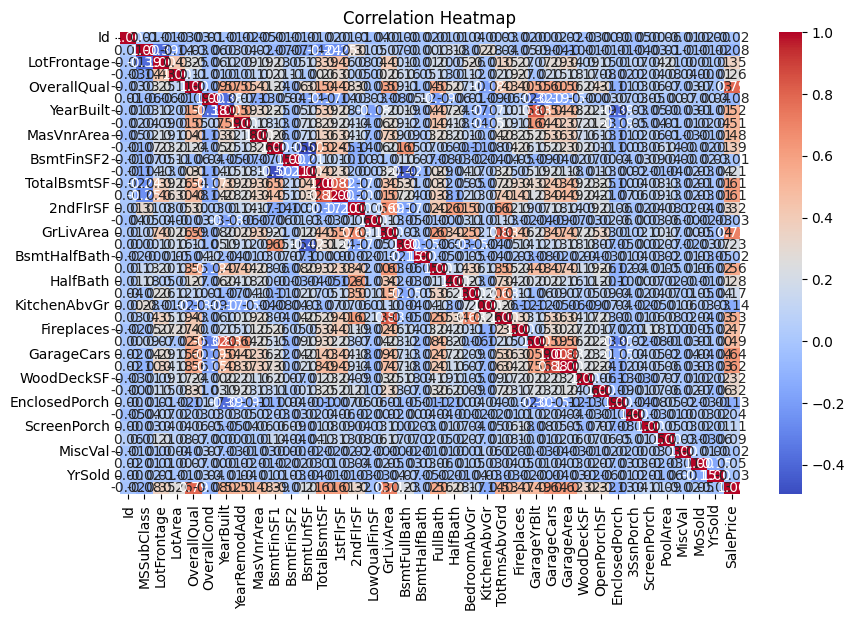

In [243]:
corr=train.corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [244]:
train.drop(columns=['Alley','PoolQC','Fence','MiscFeature'],axis=1,inplace=True)

In [245]:
test.drop(columns=['Alley','PoolQC','Fence','MiscFeature'],axis=1,inplace=True)

In [246]:
train.isnull().sum().sum()


np.int64(2422)

In [247]:
# List of categorical features where NaN means "None"
features_fill_none = [
    'MasVnrType', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond'
]

for col in features_fill_none:
    train[col] = train[col].fillna('None')

In [248]:
for col in features_fill_none:
    test[col] = test[col].fillna('None')

In [249]:
# List of numerical features to fill with 0
features_fill_zero = ['MasVnrArea', 'GarageYrBlt']

for col in features_fill_zero:
    train[col] = train[col].fillna(0)
for col in features_fill_zero:
    test[col] = test[col].fillna(0)

In [250]:
train['LotFrontage'] = train['LotFrontage'].fillna(train['LotFrontage'].median())
test['LotFrontage'] = test['LotFrontage'].fillna(test['LotFrontage'].median())

In [251]:
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])
test['Electrical'] = test['Electrical'].fillna(test['Electrical'].mode()[0])

In [252]:
ordinal_features = [
    'LotShape',
    'Utilities',
    'LandSlope',
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtFinType2',
    'HeatingQC',
    'CentralAir',
    'KitchenQual',
    'Functional',
    'FireplaceQu',
    'GarageFinish',
    'GarageQual',
    'GarageCond',
    'PavedDrive'
]
len(ordinal_features)

19

In [253]:
nominal_features = [
    'MSZoning',
    'Street',
    'LandContour',
    'LotConfig',
    'Neighborhood',
    'Condition1',
    'Condition2',
    'BldgType',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'MasVnrType',
    'Foundation',
    'Heating',
    'Electrical',
    'GarageType',
    'SaleType',
    'SaleCondition'
]
len(nominal_features)

20

In [254]:
ordinal_feature_orders = {
    'LotShape': ['IR3', 'IR2', 'IR1', 'Reg'],
    'Utilities': ['NoSeWa', 'AllPub'],
    'LandSlope': ['Sev', 'Mod', 'Gtl'],
    'ExterQual': ['Fa', 'TA', 'Gd', 'Ex'], # Based on your data
    'ExterCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtQual': ['None', 'Fa', 'TA', 'Gd', 'Ex'], # Based on your data
    'BsmtCond': ['None', 'Po', 'Fa', 'TA', 'Gd'], # Based on your data
    'BsmtExposure': ['None', 'No', 'Mn', 'Av', 'Gd'],
    'BsmtFinType1': ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFinType2': ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'HeatingQC': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'CentralAir': ['N', 'Y'],
    'KitchenQual': ['Fa', 'TA', 'Gd', 'Ex'], # Based on your data
    'Functional': ['Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    'FireplaceQu': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageFinish': ['None', 'Unf', 'RFn', 'Fin'],
    'GarageQual': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageCond': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'PavedDrive': ['N', 'P', 'Y']
}

In [255]:
numeric_cols=['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold']
len(numeric_cols)

36

In [ ]:
test['MSZoning'].fillna(test['MSZoning'].mode()[0],inplace=True)
test['Utilities'].fillna(test['Utilities'].mode()[0],inplace=True)
test['Exterior1st'].fillna(test['Exterior1st'].mode()[0],inplace=True)
test['Exterior2nd'].fillna(test['Exterior2nd'].mode()[0],inplace=True)
test['BsmtFinSF1'].fillna(test['BsmtFinSF1'].median(),inplace=True)
test['BsmtFinSF2'].fillna(test['BsmtFinSF2'].median(),inplace=True)
test['BsmtUnfSF'].fillna(test['BsmtUnfSF'].median(),inplace=True)
test['TotalBsmtSF'].fillna(test['TotalBsmtSF'].median(),inplace=True)
test['BsmtFullBath'].fillna(test['BsmtFullBath'].median(),inplace=True)
test['BsmtHalfBath'].fillna(test['BsmtHalfBath'].median(),inplace=True)
test['KitchenQual'].fillna(test['KitchenQual'].mode()[0],inplace=True)
test['Functional'].fillna(test['Functional'].mode()[0],inplace=True)
test['GarageCars'].fillna(test['GarageCars'].median(),inplace=True)
test['GarageArea'].fillna(test['GarageArea'].median(),inplace=True)
test['SaleType'].fillna(test['SaleType'].mode()[0],inplace=True)
test.isnull().sum()[test.isnull().sum() > 0]


In [257]:
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
Transformer=ColumnTransformer([
    ('numeric',StandardScaler(),numeric_cols),
    ('ordinal',OrdinalEncoder(categories=list(ordinal_feature_orders.values())),ordinal_features),
    ('nominal',OneHotEncoder(handle_unknown='ignore'),nominal_features)
])

In [258]:
X=train.drop(columns=['Id','SalePrice'],axis=1)
y=train['SalePrice']

In [276]:
from sklearn.model_selection import train_test_split
import numpy as np

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [277]:
y_train_log = np.log1p(y_train)

y_test_log = np.log1p(y_test)

In [278]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
model_lr=Pipeline([('Transfomer',Transformer),('model',LinearRegression())])
model_lr.fit(X_train,y_train_log)
y_pred=model_lr.predict(X_test)
mse=root_mean_squared_error(y_test_log,y_pred)
print(f"The RMSE for the Linear Regression model is: {mse}")

The RMSE for the Linear Regression model is: 0.12643400916749725


In [262]:
from xgboost import XGBRegressor
model_xgb=Pipeline([('Transfomer',Transformer),('model',XGBRegressor())])
model_xgb.fit(X_train,y_train_log)
y_pred=model_xgb.predict(X_test)
mse=root_mean_squared_error(y_test_log,y_pred)
print(f"The RMSE for the XGBoost model is: {mse}")

The RMSE for the XGBoost model is: 0.12751883093809258


In [266]:
x_final=train.drop(columns=['Id','SalePrice'],axis=1)
y_final=train['SalePrice']

In [267]:
model_final=Pipeline([('Transfomer',Transformer),('model',LinearRegression())])
model_final.fit(x_final,y_final)
y_pred_final=model_final.predict(test.drop(columns=['Id'],axis=1))

In [275]:
output=pd.DataFrame({'Id':test['Id'],'SalePrice':y_pred_final})
output.to_csv('submissionHousePrice2.csv', index=False)